In [1]:
print("EDA Notebook")

EDA Notebook


# Insurance Risk Analytics - Exploratory Data Analysis

## AlphaCare Insurance Solutions (ACIS)

### Week 3 Challenge

## Business Understanding

AlphaCare Insurance Solutions (ACIS) aims to optimize its marketing and pricing strategy using historical insurance claim data.

The objective of this analysis is to identify low-risk customer segments, understand profitability drivers, and support data-driven insurance pricing decisions.

This analysis focuses on:
- Insurance risk patterns
- Claims behavior
- Loss ratios
- Customer segmentation
- Profitability trends

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Style
sns.set_style("whitegrid")

In [19]:
df = pd.read_csv("../data/insurance_data.csv")

In [20]:
df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,1,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,4,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,1,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,0,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,4,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [21]:
df.shape

(10000, 21)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           10000 non-null  str    
 1   Age                  10000 non-null  int64  
 2   Gender               10000 non-null  str    
 3   Province             10000 non-null  str    
 4   VehicleType          10000 non-null  str    
 5   AnnualIncome         10000 non-null  int64  
 6   RiskScore            10000 non-null  int64  
 7   AnnualPremium        10000 non-null  int64  
 8   Deductible           10000 non-null  int64  
 9   NCD                  10000 non-null  int64  
 10  PastClaims           10000 non-null  int64  
 11  Claimed              10000 non-null  bool   
 12  ClaimAmount          10000 non-null  float64
 13  TotalPremium         10000 non-null  int64  
 14  TotalClaims          10000 non-null  float64
 15  CoverType            10000 non-null  str    
 16

In [23]:
df.describe()

,Age,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,ClaimAmount,TotalPremium,TotalClaims,CustomValueEstimate,ZipCode
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,46.683500,79201.97390,58.140000,2488.127900,751.700000,20.935000,1.064200,1314.188500,2488.127900,1314.188500,35640.598700,23215.00050
std,16.717963,33039.93977,14.267486,735.674491,500.509401,14.549122,1.051945,3921.864903,735.674491,3921.864903,22353.988238,12848.33245
min,18.000000,17202.00000,15.000000,951.000000,250.000000,0.000000,0.000000,0.000000,951.000000,0.000000,5022.000000,10001.00000
25%,32.000000,56105.00000,48.000000,2028.000000,500.000000,10.000000,0.000000,0.000000,2028.000000,0.000000,21442.750000,10004.00000
50%,46.000000,72942.00000,57.000000,2307.000000,500.000000,20.000000,1.000000,0.000000,2307.000000,0.000000,28522.000000,20003.00000
75%,61.000000,95092.00000,67.000000,2676.000000,1000.000000,30.000000,2.000000,0.000000,2676.000000,0.000000,46721.000000,30004.00000
max,75.000000,376916.00000,95.000000,5105.000000,2000.000000,50.000000,5.000000,49623.000000,5105.000000,49623.000000,134914.000000,50005.00000


## Data Quality Assessment

In this section, we assess:
- Missing values
- Duplicate records
- Data types
- Potential data quality issues

In [24]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [25]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent[missing_percent > 0].sort_values(ascending=False)


Series([], dtype: float64)

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.dtypes

CustomerID                 str
Age                      int64
Gender                     str
Province                   str
VehicleType                str
AnnualIncome             int64
RiskScore                int64
AnnualPremium            int64
Deductible               int64
NCD                      int64
PastClaims               int64
Claimed                   bool
ClaimAmount            float64
TotalPremium             int64
TotalClaims            float64
CoverType                  str
AutoMake                   str
VehicleModel               str
CustomValueEstimate      int64
ZipCode                  int64
TransactionDate            str
dtype: object

## Insurance Risk Metrics

Two key business metrics are calculated:

- Loss Ratio = TotalClaims / TotalPremium
- Margin = TotalPremium - TotalClaims

These metrics help measure portfolio profitability and customer risk.

In [31]:
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']

df['Margin'] = df['TotalPremium'] - df['TotalClaims']

In [32]:
df[['TotalPremium', 'TotalClaims', 'LossRatio', 'Margin']].head()

,TotalPremium,TotalClaims,LossRatio,Margin
0,2346,0.0,0.000000,2346.0
1,2334,9883.0,4.234362,-7549.0
2,1697,0.0,0.000000,1697.0
3,2370,12134.0,5.119831,-9764.0
4,2582,0.0,0.000000,2582.0


In [33]:
overall_loss_ratio = df['TotalClaims'].sum() / df['TotalPremium'].sum()

overall_loss_ratio

np.float64(0.5281836596904845)

### Interpretation

The overall portfolio loss ratio provides insight into the profitability of the insurance portfolio.

A lower loss ratio generally indicates a more profitable portfolio, while a higher loss ratio suggests increased claims costs relative to collected premiums.

## Univariate Analysis

This section explores the distribution of key financial and insurance variables to identify:
- skewness
- concentration patterns
- unusual observations
- potential outliers

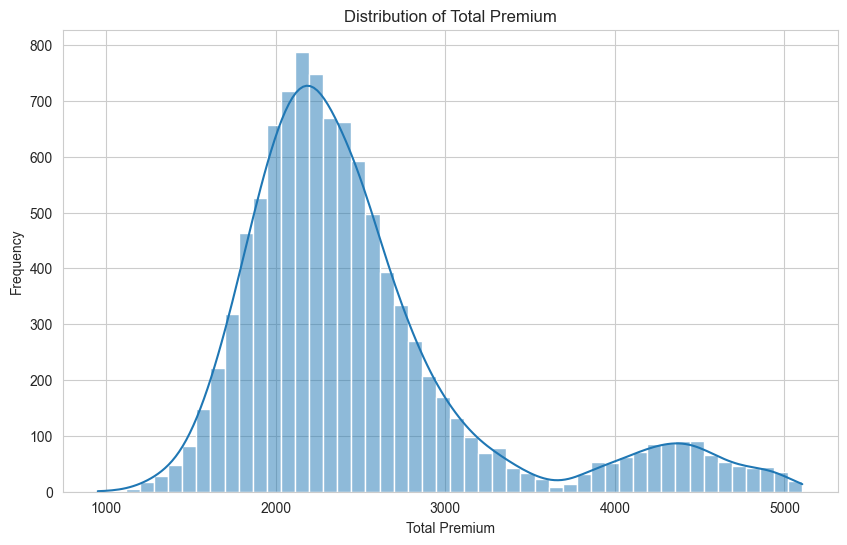

In [34]:
plt.figure(figsize=(10,6))

sns.histplot(df['TotalPremium'], bins=50, kde=True)

plt.title('Distribution of Total Premium')
plt.xlabel('Total Premium')
plt.ylabel('Frequency')

plt.show()

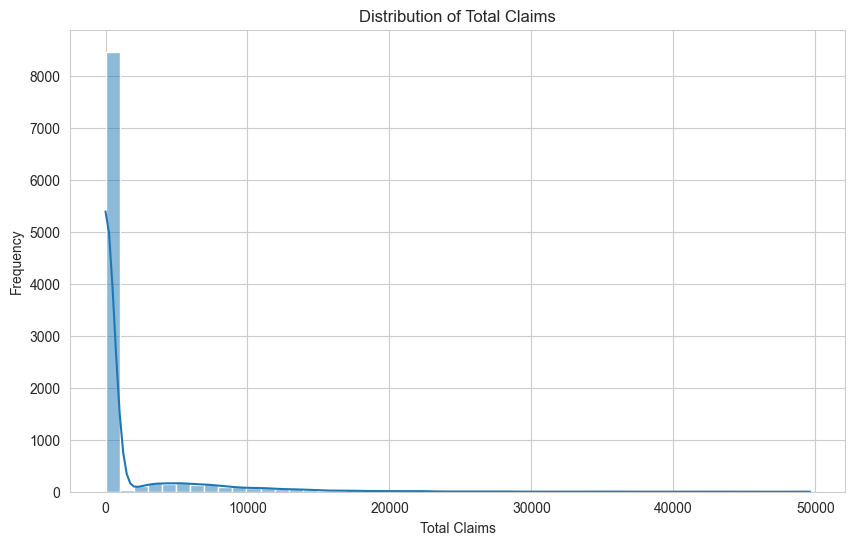

In [35]:
plt.figure(figsize=(10,6))

sns.histplot(df['TotalClaims'], bins=50, kde=True)

plt.title('Distribution of Total Claims')
plt.xlabel('Total Claims')
plt.ylabel('Frequency')

plt.show()

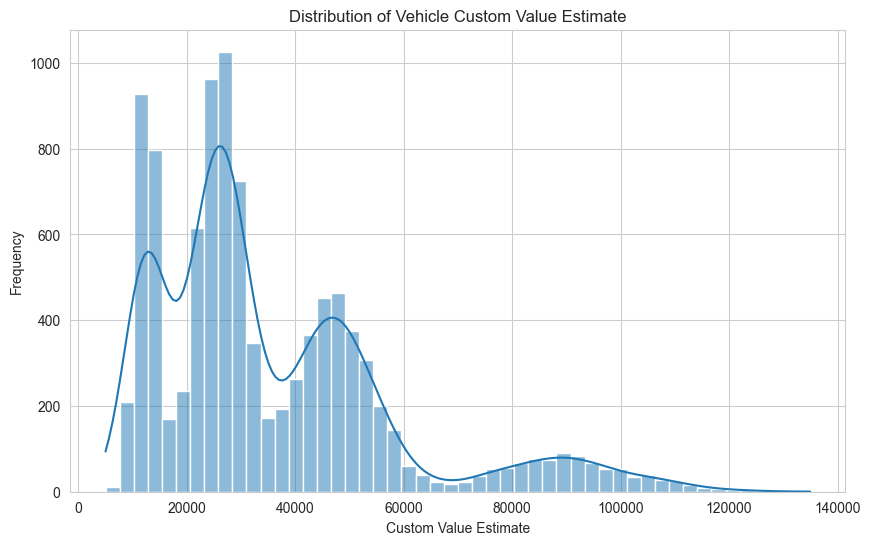

In [36]:
plt.figure(figsize=(10,6))

sns.histplot(df['CustomValueEstimate'], bins=50, kde=True)

plt.title('Distribution of Vehicle Custom Value Estimate')
plt.xlabel('Custom Value Estimate')
plt.ylabel('Frequency')

plt.show()

## Outlier Detection

Boxplots are used to identify extreme values in:
- Total Claims
- Total Premium
- Vehicle Value Estimates

Outliers may indicate:
- high-risk customers
- luxury vehicles
- fraud patterns
- rare but expensive claims

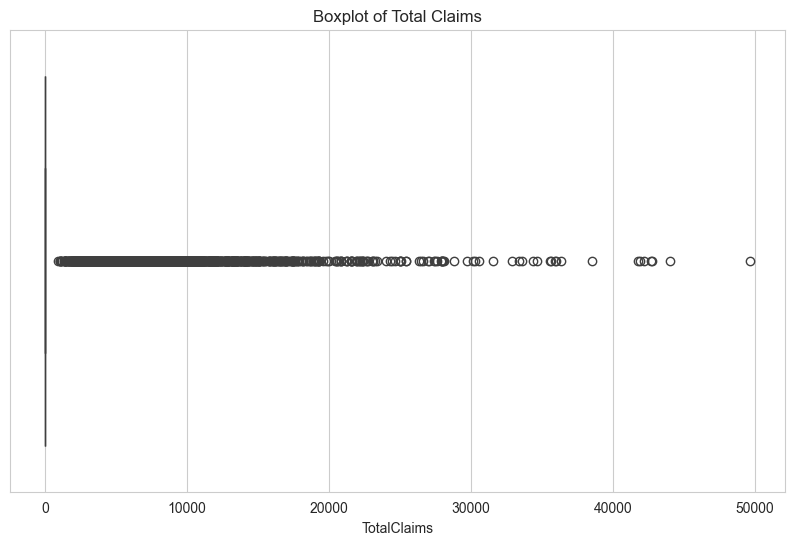

In [40]:
plt.figure(figsize=(10,6))

sns.boxplot(x=df['TotalClaims'])

plt.title('Boxplot of Total Claims')

plt.show()

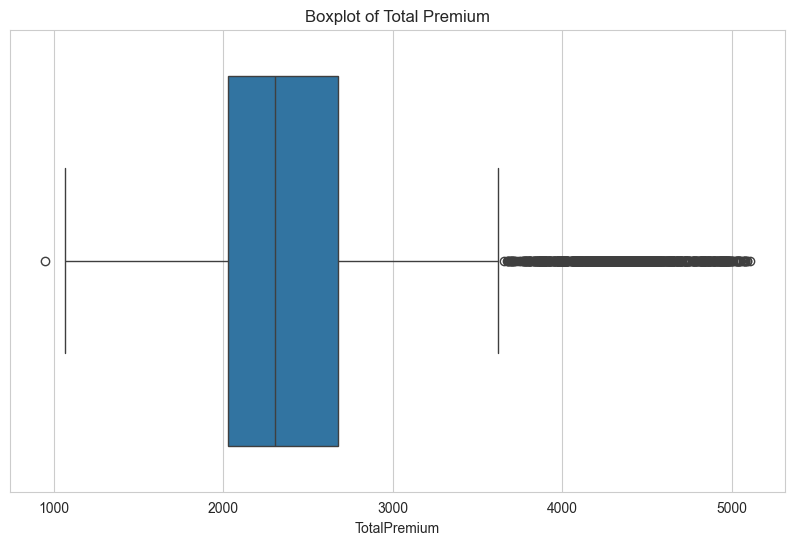

In [41]:
plt.figure(figsize=(10,6))

sns.boxplot(x=df['TotalPremium'])

plt.title('Boxplot of Total Premium')

plt.show()

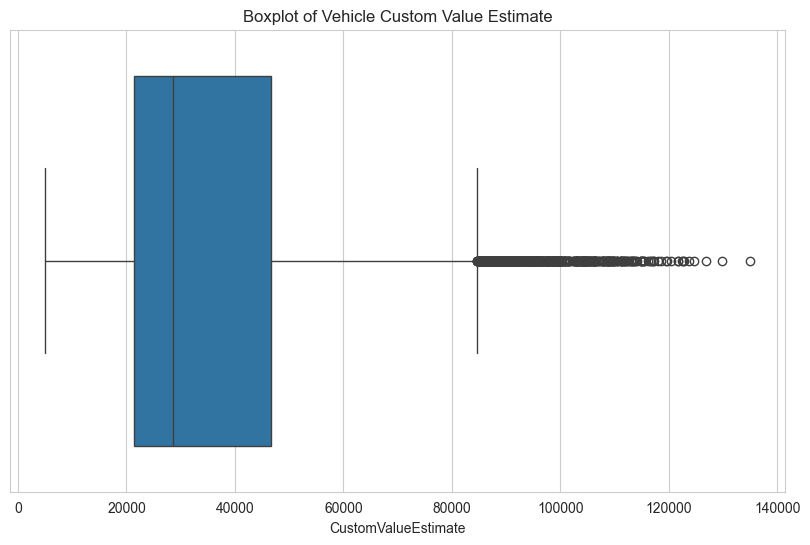

In [42]:
plt.figure(figsize=(10,6))

sns.boxplot(x=df['CustomValueEstimate'])

plt.title('Boxplot of Vehicle Custom Value Estimate')

plt.show()

### Key Insights

The distributions of Total Claims and Total Premium appear highly right-skewed, indicating that most policies involve relatively low premiums and claim amounts, while a smaller number of policies account for very high values.

The boxplots reveal the presence of significant outliers, particularly in Total Claims and Vehicle Value Estimates. These extreme values may represent high-risk policies, luxury vehicles, or rare high-cost claim events.

Such outliers are important in insurance analytics because they can strongly influence profitability, pricing models, and risk segmentation strategies.